# Clustering — K-Means, Hierarchical, DBSCAN

**Goal:** Master the three fundamental clustering algorithms and understand when each one wins.

**Why it matters:**
- Most real-world data has **no labels**. Clustering is how you find structure.
- Customer segmentation, anomaly detection, image compression, topic discovery — all rely on clustering.
- Each algorithm has a **different definition of "cluster"** → different results on the same data.

**Prerequisite:** [03-supervised-learning/04-xgboost-lightgbm.ipynb](../03-supervised-learning/04-xgboost-lightgbm.ipynb)

**Datasets:**
- Synthetic blobs (to visualize algorithm behavior)
- Mall Customer Segmentation (real data — customer spending patterns)

---

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_blobs, make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
np.random.seed(42)

print("Setup complete.")

Setup complete.


## The Three Algorithms — Intuition

### K-Means
- Partitions data into **k spherical clusters**.
- Iteratively: assign points to nearest center → recompute centers.
- **Strengths:** fast, simple, scales well.
- **Weaknesses:** must specify k, assumes spherical clusters, sensitive to outliers.

### Hierarchical (Agglomerative)
- Builds a **tree of merges**: start with each point as its own cluster, merge closest pairs.
- Result: **dendrogram** — you choose the cut level.
- **Strengths:** no need to pick k upfront, produces hierarchy.
- **Weaknesses:** O(n²) memory, slow on large data.

### DBSCAN
- Groups **dense regions**, labels sparse points as **noise (-1)**.
- Two parameters: `eps` (radius) and `min_samples` (density threshold).
- **Strengths:** finds arbitrary-shaped clusters, detects outliers, no k needed.
- **Weaknesses:** sensitive to `eps`, struggles with varying densities.

### The key idea: **there is no "correct" clustering**
Each algorithm defines "cluster" differently. On the same data, results differ.

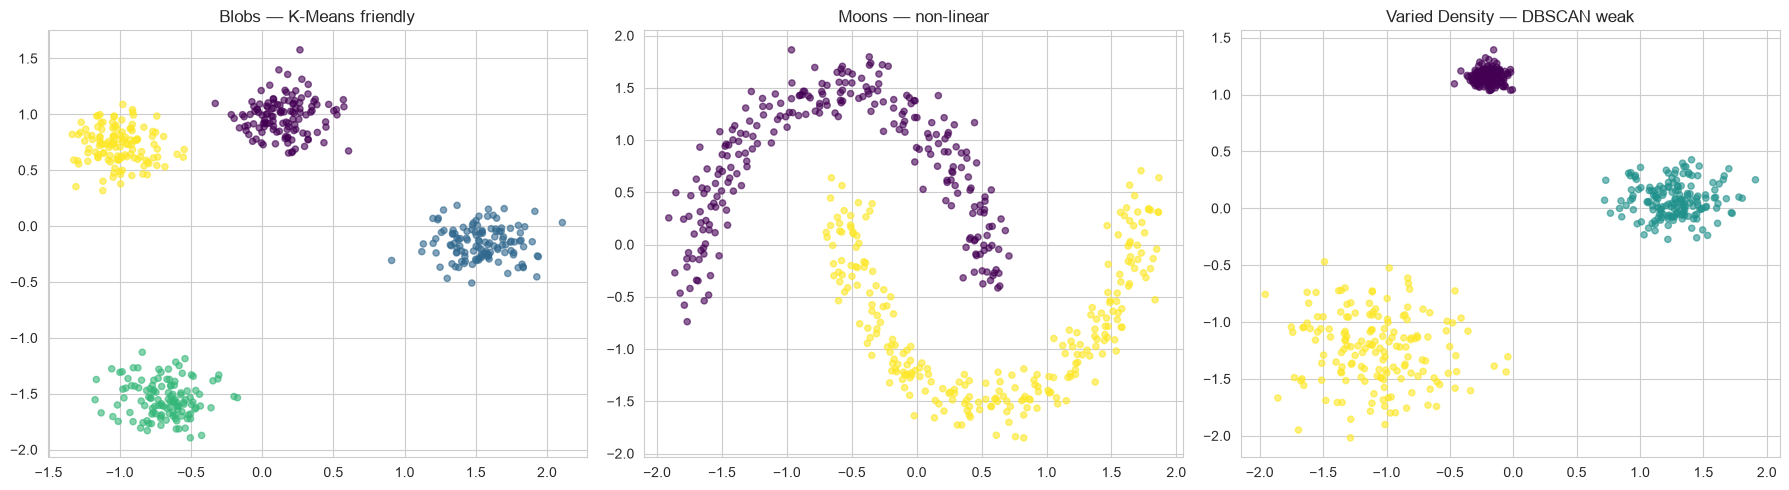

In [6]:
n_samples = 500

X_blobs , y_blobs = make_blobs(
  n_samples=n_samples,
  centers=4,
  cluster_std=1.0,
  random_state=42,
)

X_moons , y_moons = make_moons(n_samples=n_samples, noise=0.08, random_state=42)

X_var, y_var = make_blobs(
    n_samples=n_samples, centers=3, cluster_std=[0.4, 1.0, 2.0], random_state=42
)

X_blobs = StandardScaler().fit_transform(X_blobs)
X_moons = StandardScaler().fit_transform(X_moons)
X_var = StandardScaler().fit_transform(X_var)

figs, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].scatter(X_blobs[:, 0], X_blobs[:, 1], c=y_blobs, cmap="viridis", alpha=0.6, s=20)

axes[0].set_title("Blobs — K-Means friendly")
axes[1].scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, cmap="viridis", alpha=0.6, s=20)
axes[1].set_title("Moons — non-linear")
axes[2].scatter(X_var[:, 0], X_var[:, 1], c=y_var, cmap="viridis", alpha=0.6, s=20)
axes[2].set_title("Varied Density — DBSCAN weak")
plt.tight_layout()
plt.show()

K-Means on Blobs:
  Silhouette       : 0.798  (higher better, max 1)
  Davies-Bouldin   : 0.282  (lower better, min 0)
  Calinski-Harabasz: 5578.0  (higher better)


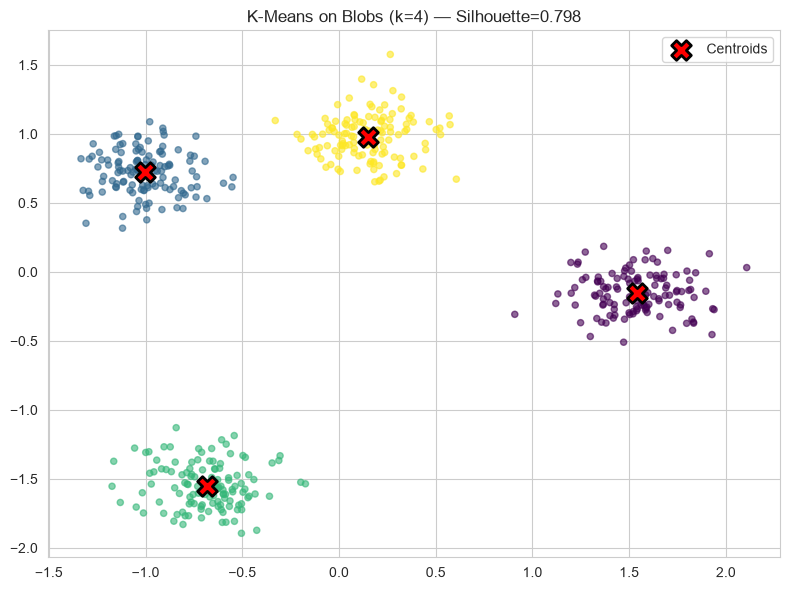

In [9]:
kmeans = KMeans(
  n_clusters=4,
  init="k-means++",
  n_init=10,
  max_iter=300,
  tol=1e-4,
  random_state=42,
  # n_jobs=-1,
)
labels_km = kmeans.fit_predict(X_blobs)

sil =silhouette_score(X_blobs, labels_km)

db = davies_bouldin_score(X_blobs, labels_km)

ch = calinski_harabasz_score(X_blobs, labels_km)

print(f"K-Means on Blobs:")
print(f"  Silhouette       : {sil:.3f}  (higher better, max 1)")
print(f"  Davies-Bouldin   : {db:.3f}  (lower better, min 0)")
print(f"  Calinski-Harabasz: {ch:.1f}  (higher better)")

# Visualize
plt.figure(figsize=(8, 6))
plt.scatter(X_blobs[:, 0], X_blobs[:, 1], c=labels_km, cmap="viridis", alpha=0.6, s=20)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            c="red", marker="X", s=200, edgecolors="black", linewidths=2, label="Centroids")
plt.title(f"K-Means on Blobs (k=4) — Silhouette={sil:.3f}")
plt.legend()
plt.tight_layout()
plt.show()

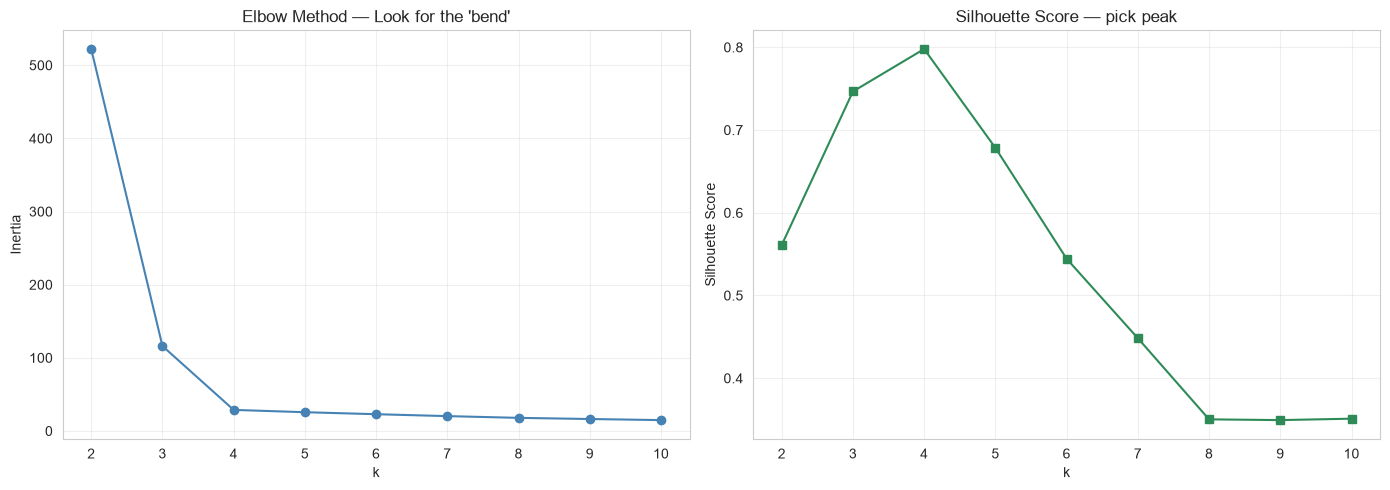

In [11]:
# Try different k and measure inertia (within-cluster sum of squares)
inertias = []
silhouettes = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(X_blobs)
    inertias.append(km.inertia_)
    # inertia_ → sum of squared distances to nearest centroid.
    #   Always decreases as k increases (more clusters = tighter).
    #   "Elbow" = where it stops dropping fast.
    silhouettes.append(silhouette_score(X_blobs, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, "o-", color="steelblue")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow Method — Look for the 'bend'")
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, silhouettes, "s-", color="seagreen")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score — pick peak")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

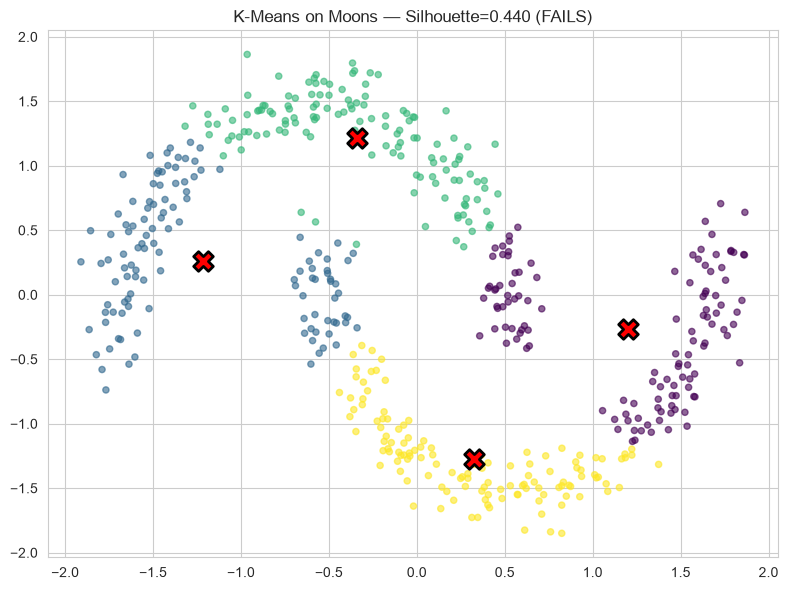

In [14]:
km_moons = KMeans(n_clusters=4, n_init=10 , random_state=42)
labels_km_moons = km_moons.fit_predict(X_moons)
sil_moons = silhouette_score(X_moons, labels_km_moons)

plt.figure(figsize=(8, 6))
plt.scatter(X_moons[:, 0], X_moons[:, 1], c=labels_km_moons, cmap="viridis", alpha=0.6, s=20)
plt.scatter(km_moons.cluster_centers_[:, 0], km_moons.cluster_centers_[:, 1],
            c="red", marker="X", s=200, edgecolors="black", linewidths=2)
plt.title(f"K-Means on Moons — Silhouette={sil_moons:.3f} (FAILS)")
plt.tight_layout()
plt.show()

DBSCAN on Moons:
  Clusters found: 2
  Noise points  : 0 (0.0%)
  Silhouette    : 0.384


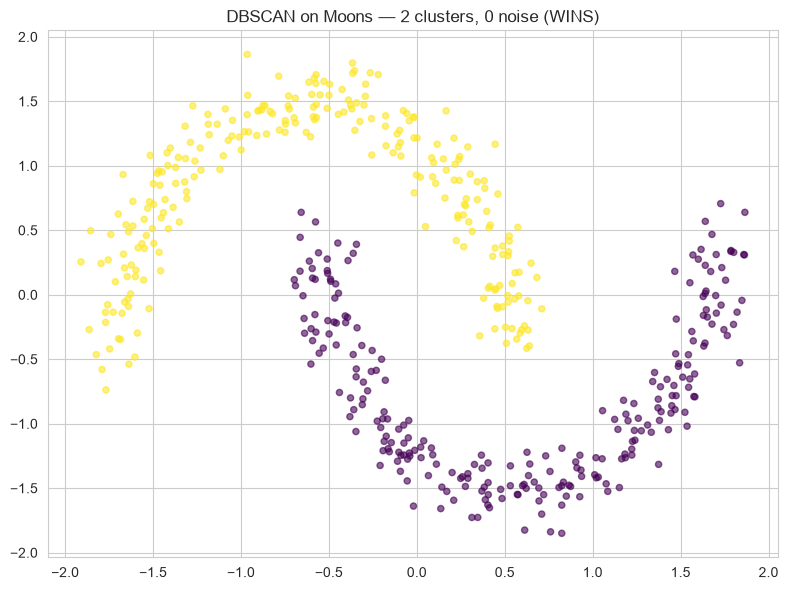

In [15]:
dbscan = DBSCAN(
  eps=0.3,
  min_samples=5,
  metric="euclidean"

)

labels_db = dbscan.fit_predict(X_moons)

n_noise = (labels_db == -1).sum()
n_clusters = len(set(labels_db)) - (1 if -1 in labels_db else 0)

print(f"DBSCAN on Moons:")
print(f"  Clusters found: {n_clusters}")
print(f"  Noise points  : {n_noise} ({n_noise/len(labels_db)*100:.1f}%)")

if n_clusters >= 2:
  mask = labels_db != -1
  sil_db = silhouette_score(X_moons[mask], labels_db[mask])
  print(f"  Silhouette    : {sil_db:.3f}")

plt.figure(figsize=(8, 6))
plt.scatter(X_moons[:, 0], X_moons[:, 1], c=labels_db, cmap="viridis", alpha=0.6, s=20)
plt.title(f"DBSCAN on Moons — {n_clusters} clusters, {n_noise} noise (WINS)")
plt.tight_layout()
plt.show() 


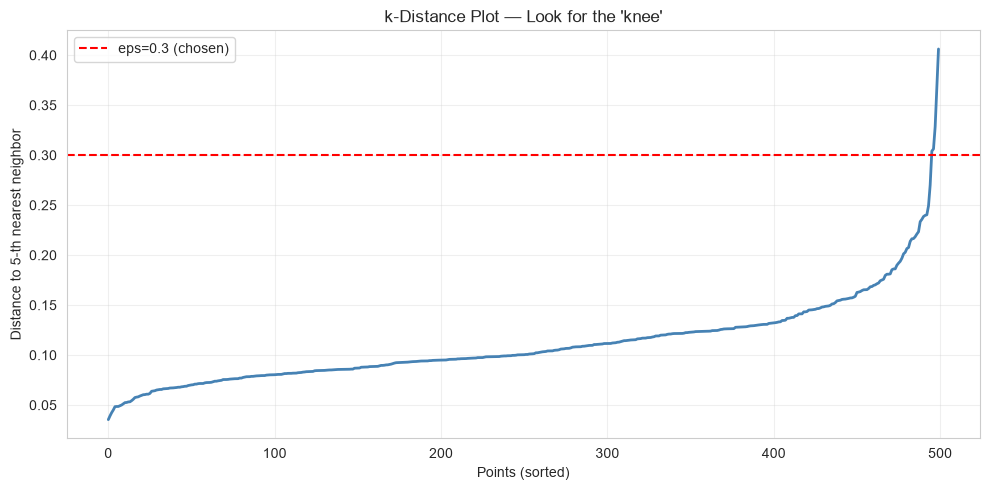

In [16]:
k = 5 

neighbors = NearestNeighbors(n_neighbors=k)
neighbors.fit(X_moons)
distances, indices = neighbors.kneighbors(X_moons)

k_distances = np.sort(distances[:, k-1])

plt.figure(figsize=(10, 5))
plt.plot(k_distances, color="steelblue", linewidth=2)
plt.axhline(y=0.3, color="red", linestyle="--", label="eps=0.3 (chosen)")
plt.xlabel("Points (sorted)")
plt.ylabel(f"Distance to {k}-th nearest neighbor")
plt.title("k-Distance Plot — Look for the 'knee'")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


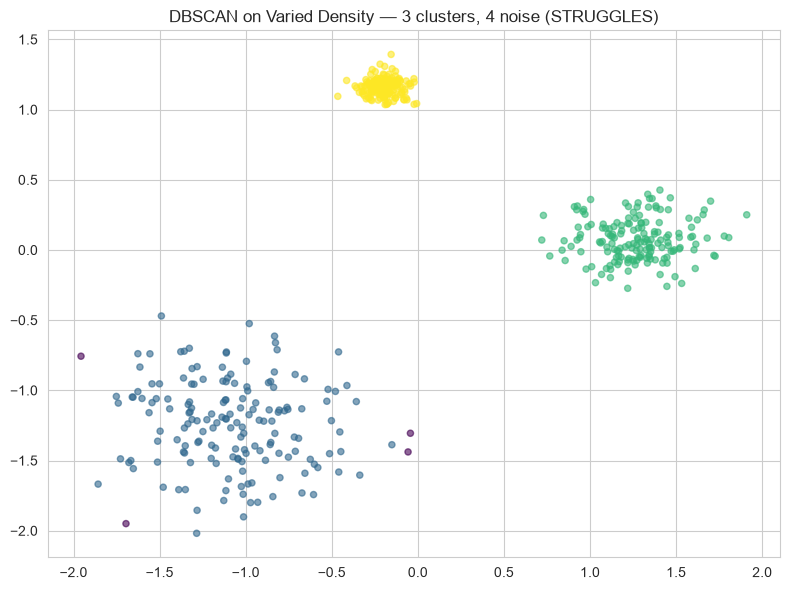

In [17]:
labels_db_var = DBSCAN(eps=0.3, min_samples=5, n_jobs=-1).fit_predict(X_var)

n_noise = (labels_db_var == -1).sum()
n_clusters = len(set(labels_db_var)) - (1 if -1 in labels_db_var else 0)

plt.figure(figsize=(8, 6))
plt.scatter(X_var[:, 0], X_var[:, 1], c=labels_db_var, cmap="viridis", alpha=0.6, s=20)
plt.title(f"DBSCAN on Varied Density — {n_clusters} clusters, {n_noise} noise (STRUGGLES)")
plt.tight_layout()
plt.show()

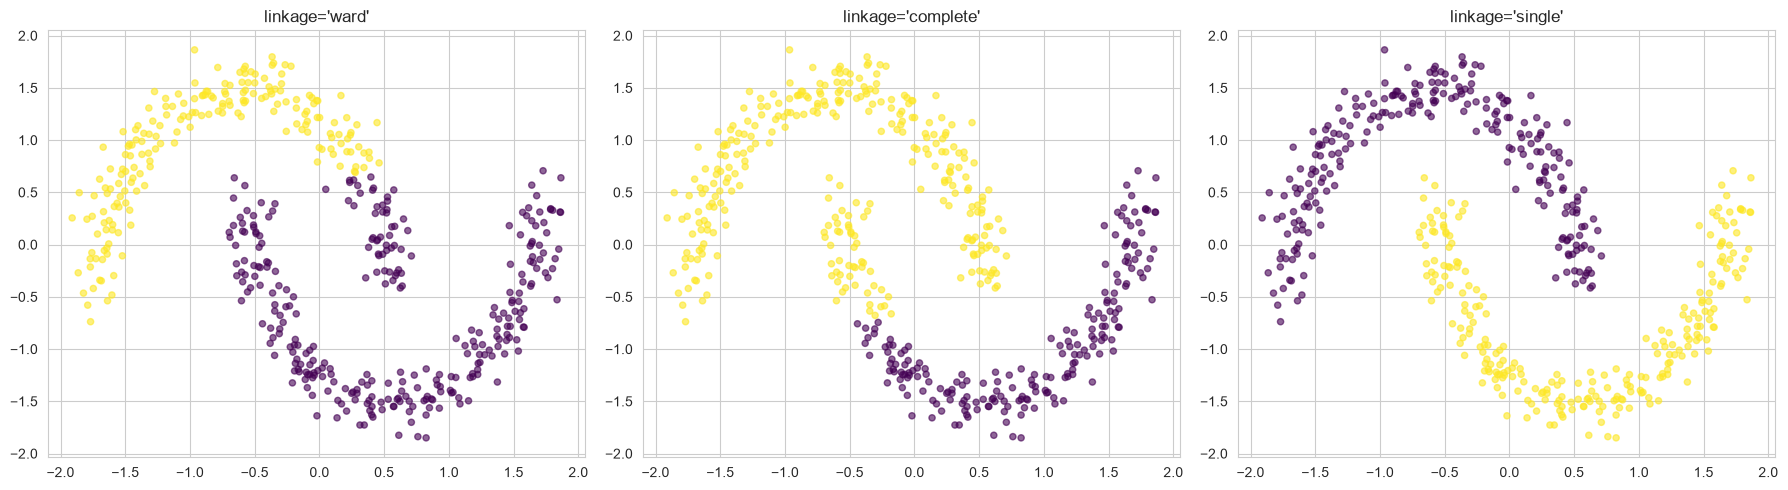

In [18]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, linkage_method in zip(axes, ["ward", "complete", "single"]):
    hc = AgglomerativeClustering(
        n_clusters=2,
        linkage=linkage_method,
        
        metric="euclidean",
    )
    labels = hc.fit_predict(X_moons)
    ax.scatter(X_moons[:, 0], X_moons[:, 1], c=labels, cmap="viridis", alpha=0.6, s=20)
    ax.set_title(f"linkage='{linkage_method}'")

plt.tight_layout()
plt.show()